Slope (m): 0.60
Intercept (c): 2.20


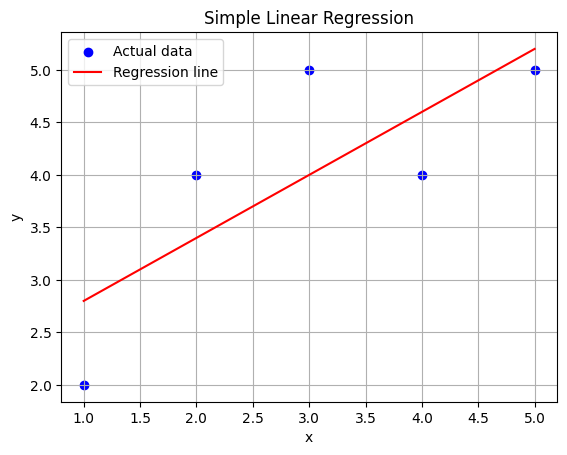

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 5], dtype=float)

# Calculate the mean of x and y
x_mean = np.mean(x)
y_mean = np.mean(y)

# Calculate coefficients (slope m and intercept c)
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)
m = numerator / denominator
c = y_mean - m * x_mean

print(f"Slope (m): {m:.2f}")
print(f"Intercept (c): {c:.2f}")

# Predict values
y_pred = m * x + c

# Plot original points and the regression line
plt.scatter(x, y, color='blue', label='Actual data')
plt.plot(x, y_pred, color='red', label='Regression line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simple Linear Regression')
plt.legend()
plt.grid(True)
plt.show()


In [2]:
x_mean

3.0

In [3]:
numerator

6.0

In [4]:
def compute_cost(x, y, m, c):
    n = len(y)
    y_pred = m * x + c
    cost = np.sum((y - y_pred) ** 2) / n
    return cost

# Calculate cost
cost = compute_cost(x, y, m, c)
print(f"Cost (MSE): {cost:.2f}")


Cost (MSE): 0.48


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 5], dtype=float)

# Initialize parameters
m = 0.0  # slope
c = 0.0  # intercept
lr = 0.01  # learning rate
epochs = 1001  # number of iterations
n = len(x)

# Gradient descent
for epoch in range(epochs):
    y_pred = m * x + c
    error = y - y_pred
    
    # Compute gradients
    #
    dm = (-2/n) * np.sum(x * error)
    dc = (-2/n) * np.sum(error)
    
    # Update weights
    m -= lr * dm
    c -= lr * dc

    # Print loss every 100 epochs
    if epoch % 100 == 0:
        loss = np.mean(error**2)
        print(f"Epoch {epoch}: Loss = {loss:.4f}, m = {m:.4f}, c = {c:.4f}")

# Final parameters
print(f"\nFinal slope (m): {m:.2f}")
print(f"Final intercept (c): {c:.2f}")


Epoch 0: Loss = 17.2000, m = 0.2640, c = 0.0800
Epoch 100: Loss = 0.8099, m = 0.9716, c = 0.8583
Epoch 200: Loss = 0.6476, m = 0.8649, c = 1.2437
Epoch 300: Loss = 0.5651, m = 0.7888, c = 1.5185
Epoch 400: Loss = 0.5232, m = 0.7345, c = 1.7143
Epoch 500: Loss = 0.5020, m = 0.6959, c = 1.8538
Epoch 600: Loss = 0.4912, m = 0.6683, c = 1.9533
Epoch 700: Loss = 0.4857, m = 0.6487, c = 2.0241
Epoch 800: Loss = 0.4829, m = 0.6347, c = 2.0747
Epoch 900: Loss = 0.4815, m = 0.6247, c = 2.1107
Epoch 1000: Loss = 0.4807, m = 0.6176, c = 2.1363

Final slope (m): 0.62
Final intercept (c): 2.14


In [8]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)   # Residual sum of squares
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  # Total sum of squares
    return 1 - (ss_res / ss_tot)

In [9]:
import numpy as np

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Binary Cross-Entropy Loss
def compute_loss(y, y_pred):
    epsilon = 1e-15  # avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

# Logistic Regression Model
def logistic_regression(X, y, lr=0.01, epochs=1000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0

    for epoch in range(epochs):
        # Linear model
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        # Gradients
        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (1 / n_samples) * np.sum(y_pred - y)

        # Update weights
        w -= lr * dw
        b -= lr * db

        # Print loss every 100 epochs
        if epoch % 100 == 0:
            loss = compute_loss(y, y_pred)
            print(f"Epoch {epoch}: Loss = {loss:.4f}")

    return w, b

# Prediction function
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(np.dot(X, w) + b)
    return (probs >= threshold).astype(int)

# Example data (binary classification: OR logic)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 1])

# Train model
w, b = logistic_regression(X, y, lr=0.1, epochs=1000)

# Predict
y_pred = predict(X, w, b)
print("\nPredictions:", y_pred)
print("Ground truth:", y)


Epoch 0: Loss = 0.6931
Epoch 100: Loss = 0.3423
Epoch 200: Loss = 0.2669
Epoch 300: Loss = 0.2174
Epoch 400: Loss = 0.1825
Epoch 500: Loss = 0.1568
Epoch 600: Loss = 0.1371
Epoch 700: Loss = 0.1215
Epoch 800: Loss = 0.1090
Epoch 900: Loss = 0.0987

Predictions: [0 1 1 1]
Ground truth: [0 1 1 1]
